In [ ]:

import matplotlib.pyplot as plt
from seeg_tool import *

import nibabel as nib
import pandas as pd
import numpy as np
import scipy.io 
import mne
import os
import sys



in_path = r"E:/workspace/study2_escape_task_seeg/seeg7_roi_data/hippo/" # 分析哪个roi就输入哪个文件夹的数据

behavior_path = "E:/workspace/study2_escape_task_seeg/behavior/" # 分析哪个roi就输入哪个文件夹的数据



subjects = [134, 135,137,138,148,150,151,154, 161, 162] # 所有好的被试


# subjects = [134, 135, 138, 150, 161,162]  # vmpfc
# subjects = [134, 135, 137, 138, 148, 161, 162]  # amy
subjects = [134, 135,137,138,150,151,154, 161, 162] # hippo subjects = [134, 135,137,138,148,150,151,154] # hippo

# subjects = [134, 135, 138,150,151,154,161,162] # insula    [134, 135, 138, 148, 150,151,154] 

# subjects = [135, 150,154] # mcc    [134, 135, 138, 148, 150,151,154] 




9

In [71]:
from joblib import Parallel, delayed
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler

def compute_cluster_p_value(cluster_stat, cluster_stats_H0):

    return sum(ms > (cluster_stat) for ms in cluster_stats_H0) / len(cluster_stats_H0)

def find_1d_cluster(t_maps, p_maps, p_thresh=0.05, cluster_min_size=2, tail=0):
    # 输出的数据为[(起始位置, 结束位置+1), (起始位置, 结束位置+1)]
    if tail == 1:
        mask = ((t_maps > 0) & (p_maps < p_thresh)).astype(int)
    elif tail == -1:
        mask = ((t_maps < 0) & (p_maps < p_thresh)).astype(int)
    elif tail == 0:
        mask = (p_maps < p_thresh).astype(int)
    # 找连续的1
    start = -1  # 起始位置
    length = 0  # 连续1的长度
    results = []  # 存储结果

    for i in range(len(mask)):
        if mask[i] == 1:
            if start == -1:
                start = i
            length += 1
        else:
            if length >= cluster_min_size:
                results.append((start, start + length))
            start = -1
            length = 0

    # 处理连续1在数组末尾的情况
    if length >= cluster_min_size:
        results.append((start, start + length))

    return results


def compute_cluster_stats(stat_map, clusters):
    return [abs(stat_map[cluster[0]: cluster[1]].sum()) for cluster in clusters]

def one_d_glm(regress_data, regressors_design_dict, model_formula):
    def fit_model(iter_time_point):
        data = regressors_design_dict.copy()
        data['EEG'] = regress_data[:, iter_time_point]
        model = smf.ols(formula=model_formula, data=data)
        result = model.fit()
        conf_int = result.conf_int().values  # Get confidence intervals
        return result.params.values, result.tvalues.values, result.pvalues.values, conf_int, result.bse.values

    num_cores = 4
    results = Parallel(n_jobs=num_cores)(delayed(fit_model)(iter_time_point) for iter_time_point in range(regress_data.shape[1]))

    paramap, tmap, pmap, conf_int_map, bse_map = zip(*results)
    return np.array(paramap), np.array(tmap), np.array(pmap), np.array(conf_int_map), np.array(bse_map)



In [72]:
def one_d_glm_sts(regress_data, regressors_design_dict, model_formula):
    def fit_model(iter_time_point):
        data = regressors_design_dict.copy()
        # 初始化 StandardScaler
        scaler = StandardScaler()
        # 对数据进行标准化
        scaled_data = scaler.fit_transform(data)
        # 将标准化后的数据转换为 DataFrame
        scaled_df = pd.DataFrame(scaled_data, columns=data.keys())
        scaled_df['EEG'] = regress_data[:, iter_time_point]
        model = smf.ols(formula=model_formula, data=scaled_df)
        result = model.fit()
        conf_int = result.conf_int().values  # Get confidence intervals
        return result.params.values, result.tvalues.values, result.pvalues.values, conf_int, result.bse.values

    num_cores = 6
    results = Parallel(n_jobs=num_cores)(delayed(fit_model)(iter_time_point) for iter_time_point in range(regress_data.shape[1]))

    paramap, tmap, pmap, conf_int_map, bse_map = zip(*results)
    return np.array(paramap), np.array(tmap), np.array(pmap), np.array(conf_int_map), np.array(bse_map)


In [75]:
#个体水平
from mne.time_frequency import tfr_morlet



freqs=np.arange(70, 120, 5)
n_cycles=10
# n_cycles=freqs/10
time_span = 100


freqs=np.arange(4, 31, 1) # 4 5 6 7     8 9 10 11 12 13
n_cycles = np.linspace(2, 5, num=27)
freqs = freqs[0:4]  # theta
n_cycles = n_cycles[0:4]
time_span = 5



# n_cycles =4
# time_span = 100
ch_names = []
decision_time_range = [-1.0, 3] # decision前后  0.9
baseline_range = [-1.1, 1.0]  # baseline前后 0.3s

# 生成时间序列
time_range = np.arange(baseline_range[0]-baseline_range[1] + decision_time_range[0], decision_time_range[1], 0.001)

all_sub_imminent_data = []
all_sub_moderate_data = []
imminent_trial_num, moderate_trial_num = 0, 0
all_epoch_tfr_data= {}
for i in range(len(subjects)):

    # 导入数据 删除眼电 设置电极位置
    ROI_epochs = mne.read_epochs_eeglab(in_path + str(subjects[i]) + '.set')
    # EEG_epochs = mne.read_epochs_eeglab(epoch_path + 'sub' + str(subjects[i]) + '_2_1.set')

    ROI_epochs.crop(-1.1, 16)
    # 降采样

    # 导入行为数据
    hebavior_trial = pd.read_excel(behavior_path + str(subjects[i]) + '/subject_v4.xlsx')

    print(len(hebavior_trial))

    # print(len(hebavior_trial))

    # safe_imminent_event_num = np.squeeze(np.where((hebavior_trial['event_num']==22) & ~(hebavior_trial['firsttime_stage_3'].str.len() > 0)))

    # 统一计算tfr
    # tfr_epochs_nothreat = tfr_morlet(EEG_epochs[nothreat_event_num], freqs, n_cycles=n_cycles, return_itc=False, average = False, use_fft=True, n_jobs=4)
    tfr_all_epoch = tfr_morlet(ROI_epochs, freqs, n_cycles=n_cycles, return_itc=False, average = False, use_fft=True, n_jobs=5)

    # 基线校正
    tfr_all_epoch.apply_baseline(mode='zlogratio', baseline=(-0.5, -0.1)) # 'mean' | 'ratio' | 'logratio' | 'percent' | 'zscore' | 'zlogratio'
    
    # tfr_all_epoch = apply_zlogratio_baseline(tfr_all_epoch, [-0.5, -0.1])
    # tfr_all_epoch.apply_baseline(mode='mean', baseline=(-0.5, -0.1)) 


    # create a new epochs info
    info = mne.create_info(ch_names = ROI_epochs.ch_names, ch_types = 'eeg', sfreq = 1000)

    # create a new ROI based epochs
    # tfr_all_epoch.data = gaussian_filter(data=tfr_all_epoch.data, time_span=time_span, fs=ROI_epochs.info['sfreq'])  # 如果是theta就注释掉

    tfr_all_epoch_mne = mne.EpochsArray(data = np.mean(tfr_all_epoch.data, axis=2), info = info, tmin=ROI_epochs.tmin)
    # all_sub_imminent_epoch.apply_baseline(baseline=(baseline_range[0]-baseline_range[1]+decision_time_range[0]+0.6, baseline_range[0]-baseline_range[1]+decision_time_range[0]+1.0)) #  -0.5 -0.1
    # all_sub_moderate_epoch.apply_baseline(baseline=(baseline_range[0]-baseline_range[1]+decision_time_range[0]+0.6, baseline_range[0]-baseline_range[1]+decision_time_range[0]+1.0))
    tfr_all_epoch_mne.crop(-1, 16)
    tfr_all_epoch_mne.resample(100)

    all_epoch_tfr_data[i] = tfr_all_epoch_mne
    # output_path = 'E:/workspace/study2_escape_task_eeg/tfr_data/all_trial_data_zlogratio_51_theta_allepochbaseline/'
    # tfr_all_epoch_mne.save(output_path + str(subjects[i])+ 'tfr.fif', overwrite=True)


Extracting parameters from E:/workspace/study2_escape_task_seeg/seeg7_roi_data/hippo_v2/134.set...
Not setting metadata
Not setting metadata
90 matching events found
No baseline correction applied
0 projection items activated
Ready.


<ipython-input-75-f702469898b6>:36: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  ROI_epochs = mne.read_epochs_eeglab(in_path + str(subjects[i]) + '.set')
<ipython-input-75-f702469898b6>:39: RuntimeWarning: tmax is not in epochs time interval. tmax is set to epochs.tmax
  ROI_epochs.crop(-1.1, 16)


90


[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.


Not setting metadata
Applying baseline correction (mode: zlogratio)
Not setting metadata
Not setting metadata
90 matching events found
No baseline correction applied


...

[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.


Not setting metadata


[Parallel(n_jobs=5)]: Done   7 out of   9 | elapsed:    1.4s remaining:    0.3s
[Parallel(n_jobs=5)]: Done   9 out of   9 | elapsed:    1.5s remaining:    0.0s
[Parallel(n_jobs=5)]: Done   9 out of   9 | elapsed:    1.5s finished


Applying baseline correction (mode: zlogratio)
Not setting metadata
Not setting metadata
90 matching events found
No baseline correction applied
0 projection items activated
0 bad epochs dropped


<ipython-input-75-f702469898b6>:71: RuntimeWarning: tmax is not in epochs time interval. tmax is set to epochs.tmax
  tfr_all_epoch_mne.crop(-1, 16)


In [ ]:
#个体水平
from mne.time_frequency import tfr_morlet
from tqdm import *
time_span = 100
ch_names = []
decision_time_range = [-1.0, 3] # decision前后  0.9
baseline_range = [-1.1, 1.0]  # baseline前后 0.3s
time_range = [-0.5, 1.0]  # baseline前后 0.3s

# subjects=[47]
all_sub_paramap = []
all_sub_tmap = []
all_sub_pmap = []

all_sub_paramap_dict = {}
all_sub_tmap_dict = {}
all_sub_pmap_dict = {}
imminent_trial_num, moderate_trial_num = [], []
for i in range(len(subjects)):

    # 导入数据 删除眼电 设置电极位置
    EEG_epochs = all_epoch_tfr_data[i]

    # 导入行为数据
    hebavior_trial = pd.read_excel(behavior_path + str(subjects[i]) + '/subject_v4.xlsx')
    # 补充编号序列用来后续提出epoch
    hebavior_trial['index'] = range(len(hebavior_trial))

    # 定义需要保留的列
    columns_to_keep = [
        's_safe_first_distance_stage_3',
        's_p_first_distance_stage_3',
        'rt_stage34',
        'mean_dv_stage2',
        'mean_dv_stage3',
        'mean_dv_stage4',
        'stationary_ratio_stage_3',
        'event_num',
        'index',
        'get_caught',
        'get_safe',
        'too_fast',
        'trial_time',
        'firsttime_stage_2',
        'firsttime_stage_3',
        'firsttime_stage_4',
        'firsttime_stage_5'
    ]

    # 只保留指定的列
    hebavior_trial = hebavior_trial[columns_to_keep]
    # print((hebavior_trial))

    # 检查指定列中是否存在 NaN 或空集 []，并删除这些行
    columns_to_check = [
    's_safe_first_distance_stage_3',
    'rt_stage34',
    'mean_dv_stage3',
    'stationary_ratio_stage_3',
    'firsttime_stage_3',
    's_p_first_distance_stage_3'
    ]
    
    mask = (
        hebavior_trial[columns_to_check].isna() |  # 检查 NaN
        hebavior_trial[columns_to_check].applymap(lambda x: x == [])  # 检查空集 []
            ).any(axis=1)  # 如果任意一列满足条件，则标记为 True

    # 删除满足条件的行
    hebavior_trial = hebavior_trial[~mask]

    # 提取不同条件是第几个试次
    # nothreat_event_num = np.squeeze(np.where(hebavior_trial['event_num']==11))
    # safe_direct_event_num = np.squeeze(np.where((hebavior_trial['event_num']==22) & (hebavior_trial['get_safe']==1)))
    # safe_divert_event_num = np.squeeze(np.where(( ((hebavior_trial['event_num']==32) | (hebavior_trial['event_num']==31)) & (hebavior_trial['get_safe']==1)) & (hebavior_trial['too_fast']==0)))
    # safe_divert_event_num = np.squeeze(np.where(( ((hebavior_trial['event_num']==32) | (hebavior_trial['event_num']==31)) & (hebavior_trial['get_safe']==1)) ))

    safe_direct_event_num = np.squeeze(np.where((hebavior_trial['event_num']==22)))
    safe_divert_event_num = np.squeeze(np.where(( hebavior_trial['event_num']==32) | (hebavior_trial['event_num']==31)) ) 

    direct_behavior = hebavior_trial.iloc[safe_direct_event_num]
    divert_behavior = hebavior_trial.iloc[safe_divert_event_num]

    ################################ stage 1
    direct_epoch = EEG_epochs.copy()[np.array(direct_behavior['index'])]
    divert_epoch = EEG_epochs.copy()[np.array(divert_behavior['index'])]
    direct_epoch.crop(time_range[0], time_range[1])
    divert_epoch.crop(time_range[0], time_range[1])
    
    ################################ stage 3
    # 高威胁攻击
    discarded_trial_1 = []
    empty_or_not = 0
    for iter_index in np.array(direct_behavior['index']):

        # 结合每个trial的数据确定每个trial要截取的时间窗
        iter_trialtime = time_range + np.array(round(float(direct_behavior['firsttime_stage_3'][iter_index]),2))
        if iter_trialtime[1] < 16 - 0.5: # 时间太长的就不用了
            # 利用mne的函数截取数据
            iter_safe_imminent_data = EEG_epochs.copy()[iter_index].crop(iter_trialtime[0], iter_trialtime[1]-0.010).get_data()

            # 存储数据
            if empty_or_not == 0: 
                iter_subject_safe_imminent_data = iter_safe_imminent_data
                empty_or_not = 1
            else: 
                iter_subject_safe_imminent_data = np.vstack((iter_subject_safe_imminent_data, iter_safe_imminent_data))
        else:
            discarded_trial_1.append(iter_index)

    # 低威胁攻击
    discarded_trial_2 = []
    empty_or_not = 0
    for iter_index in np.array(divert_behavior['index']):

        # 结合每个trial的数据确定每个trial要截取的时间窗
        iter_trialtime = time_range + np.array(round(float(divert_behavior['firsttime_stage_3'][iter_index]),2))
        if iter_trialtime[1] < 16-0.5: # 时间太长的就不用了
            # 利用mne的函数截取数据
            iter_safe_moderate_data = EEG_epochs.copy()[iter_index].crop(iter_trialtime[0], iter_trialtime[1]-0.010).get_data()

            # 存储数据
            if empty_or_not == 0: 
                iter_subject_safe_moderate_data = iter_safe_moderate_data
                empty_or_not = 1
            else: 
                iter_subject_safe_moderate_data = np.vstack((iter_subject_safe_moderate_data, iter_safe_moderate_data))
        else:
            discarded_trial_2.append(iter_index)


    # 用mne数据格式存储
    info = mne.create_info(ch_names = EEG_epochs.ch_names, ch_types = 'eeg', sfreq = EEG_epochs.info['sfreq'])

    # 矫正前平均
    iter_sub_imminent_epoch = mne.EpochsArray(data = iter_subject_safe_imminent_data, info = info, tmin=time_range[0])
    iter_sub_moderate_epoch = mne.EpochsArray(data = iter_subject_safe_moderate_data, info = info, tmin=time_range[0])
    # iter_sub_imminent_epoch.apply_baseline(baseline = (-0.5,-0.1))
    # iter_sub_moderate_epoch.apply_baseline(baseline = (-0.5,-0.1)) 
    if len(discarded_trial_1) > 0:
        direct_behavior.drop(index=discarded_trial_1, inplace=True)
    if len(discarded_trial_2) > 0:
        divert_behavior.drop(index=discarded_trial_2, inplace=True)
    
    imminent_trial_num.append(len(direct_behavior))
    moderate_trial_num.append(len(divert_behavior))
    ## 开始回归

    from tqdm import tqdm


    # model_formula = 'EEG ~ low_mean_dv_stage3 + low_mean_rt_stage34 + low_stationary_ratio_stage_3 + low_p_psafe_distance'
    model_formula = 'EEG ~ mean_dv_stage3 + rt_stage34 + s_safe_first_distance_stage_3 + stationary_ratio_stage_3'

    # model_formula = 'EEG ~ mean_dv_stage3 + rt_stage34 + stationary_ratio_stage_3'

    # model_formula = 'EEG ~ low_p_psafe_distance'

    # model_formula = 'EEG ~ low_p_psafe_distance '
    # 放入数据
    # 定义需要保留的列

    #################### direct
    columns_to_keep = [
        'mean_dv_stage3',
        'rt_stage34',
        's_safe_first_distance_stage_3',
        'stationary_ratio_stage_3',
    ]
    # columns_to_keep = [
    #     'mean_dv_stage3',
    #     'rt_stage34',
    #     's_p_first_distance_stage_3',
    #     'stationary_ratio_stage_3',
    # ]

    # 选择回归数据，并且只保留指定的列
    regressors_dict = direct_behavior[columns_to_keep]
    EEG_epoch_data = iter_sub_imminent_epoch
    print(len(regressors_dict))
    print(len(EEG_epoch_data))
    regressors_dict = divert_behavior[columns_to_keep]
    EEG_epoch_data = iter_sub_moderate_epoch
    print(len(regressors_dict))
    print(len(EEG_epoch_data))

    # from statsmodels.stats.outliers_influence import variance_inflation_factor
    # vif = [variance_inflation_factor(np.array(regressors_dict), i) for i in range(np.array(regressors_dict).shape[1])]
    # print(vif)
    # 把移动向量反过来
    regressors_dict['mean_dv_stage3'] = -regressors_dict['mean_dv_stage3']
    iter_sub_paramap, iter_sub_tmap, iter_sub_pmap = [], [], []
    for iter_channel in trange(len(EEG_epoch_data.ch_names)):
        regress_data = EEG_epoch_data.get_data()[:,iter_channel,:]
        # 普通回归
        paramap, tmap, pmap, _, _ = one_d_glm_sts(regress_data, regressors_design_dict=regressors_dict, model_formula=model_formula)

        iter_sub_paramap.append(paramap)
        iter_sub_tmap.append(tmap)
        iter_sub_pmap.append(pmap)

    # all_sub_paramap.append(iter_sub_paramap)
    # all_sub_tmap.append(iter_sub_tmap)
    # all_sub_pmap.append(iter_sub_pmap)

    all_sub_paramap_dict[i] = iter_sub_paramap
    all_sub_tmap_dict[i] = iter_sub_tmap
    all_sub_pmap_dict[i] = iter_sub_pmap
    # 第一行是截距


all_sub_paramap = []
all_sub_tmap = []
all_sub_pmap = []
for i in range(len(subjects)):

    if len(all_sub_paramap)==0:
        all_sub_paramap = all_sub_paramap_dict[i]
        all_sub_tmap = all_sub_tmap_dict[i]
        all_sub_pmap = all_sub_pmap_dict[i]
    else:
        all_sub_paramap = np.concatenate((all_sub_paramap, all_sub_paramap_dict[i]), axis=0)
        all_sub_all_sub_tmaparamap = np.concatenate((all_sub_tmap, all_sub_tmap_dict[i]), axis=0)
        all_sub_pmap = np.concatenate((all_sub_pmap, all_sub_pmap_dict[i]), axis=0)

Not setting metadata
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
0 bad epochs dropped
Not setting metadata
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
0 bad epochs dropped


<ipython-input-79-acb34ca711ff>:191: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  regressors_dict['mean_dv_stage3'] = -regressors_dict['mean_dv_stage3']
  0%|          | 0/2 [00:00<?, ?it/s]

30
30
30
30


100%|██████████| 2/2 [00:00<00:00,  2.22it/s]


Not setting metadata
Not setting metadata
29 matching events found
No baseline correction applied
0 projection items activated
0 bad epochs dropped
Not setting metadata
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
0 bad epochs dropped


...

100%|██████████| 5/5 [00:01<00:00,  2.80it/s]


Not setting metadata
Not setting metadata
29 matching events found
No baseline correction applied
0 projection items activated
0 bad epochs dropped
Not setting metadata
Not setting metadata
29 matching events found
No baseline correction applied
0 projection items activated
0 bad epochs dropped


<ipython-input-79-acb34ca711ff>:191: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  regressors_dict['mean_dv_stage3'] = -regressors_dict['mean_dv_stage3']
  0%|          | 0/9 [00:00<?, ?it/s]

29
29
29
29


100%|██████████| 9/9 [00:03<00:00,  2.98it/s]


In [12]:
model_formula

'EEG ~ low_mean_dv_stage3 + low_mean_rt_stage34 + low_stationary_ratio_stage_3 + low_p_psafe_distance'

In [37]:
np.array(direct_behavior[columns_to_keep]).shape

(30, 4)

In [80]:
# 存储lasso回归数据
all_sub_paramap = np.array(all_sub_paramap)
all_sub_tmap = np.array(all_sub_tmap)
all_sub_pmap = np.array(all_sub_pmap)
# 用mne的数据格式进行存储
tfr_file_path = "E:/workspace/study2_escape_task_seeg/tfr_data/" # 分析哪个roi就输入哪个文件夹的数据
tfr_type = "hga_hpc/"   # 要改
tfr_path = tfr_file_path + tfr_type
info = mne.create_info(ch_names = list(np.arange(all_sub_paramap.shape[0]).astype('str')), ch_types = 'eeg', sfreq = EEG_epochs.info['sfreq'])
result_path = tfr_path + 'nobaseline_ols_divert_ynozscore_smooth_theta/'   # baseline_elastic_ols_direct
# 检查路径是否存在
if not os.path.exists(result_path):
    # 如果路径不存在，则创建文件夹
    os.makedirs(result_path)
# mean_dv_stage3
mean_dv_stage3_paramap = mne.EvokedArray(data = all_sub_paramap[:,:,1], info = info, tmin=time_range[0])
# mean_dv_stage3_tmap = mne.EpochsArray(data = all_sub_tmap[:,:,:,1], info = info, tmin=time_range[0])
# mean_dv_stage3_pmap = mne.EpochsArray(data = all_sub_pmap[:,:,:,1], info = info, tmin=time_range[0])
mean_dv_stage3_paramap.save(result_path +  'mean_dv_stage3_paramap.fif')
# mean_dv_stage3_tmap.save(result_path +  'mean_dv_stage3_tmap.fif', overwrite=True)
# mean_dv_stage3_pmap.save(result_path +  'mean_dv_stage3_pmap.fif', overwrite=True)

# rt_stage34
rt_stage34_paramap = mne.EvokedArray(data = all_sub_paramap[:,:,2], info = info, tmin=time_range[0])
# rt_stage34_tmap = mne.EpochsArray(data = all_sub_tmap[:,:,:,2], info = info, tmin=time_range[0])
# rt_stage34_pmap = mne.EpochsArray(data = all_sub_pmap[:,:,:,2], info = info, tmin=time_range[0])
rt_stage34_paramap.save(result_path +  'rt_stage34_paramap.fif')
# rt_stage34_tmap.save(result_path +  'rt_stage34_tmap.fif', overwrite=True)
# rt_stage34_pmap.save(result_path +  'rt_stage34_pmap.fif', overwrite=True)

# s_safe_first_distance_stage_3
s_safe_first_distance_stage_3_paramap = mne.EvokedArray(data = all_sub_paramap[:,:,3], info = info, tmin=time_range[0])
# s_safe_first_distance_stage_3_tmap = mne.EpochsArray(data = all_sub_tmap[:,:,:,3], info = info, tmin=time_range[0])
# s_safe_first_distance_stage_3_pmap = mne.EpochsArray(data = all_sub_pmap[:,:,:,3], info = info, tmin=time_range[0])
s_safe_first_distance_stage_3_paramap.save(result_path +  's_safe_first_distance_stage_3_paramap.fif')
# s_safe_first_distance_stage_3_tmap.save(result_path +  's_safe_first_distance_stage_3_tmap.fif', overwrite=True)
# s_safe_first_distance_stage_3_pmap.save(result_path +  's_safe_first_distance_stage_3_pmap.fif', overwrite=True)

# s_safe_first_distance_stage_3
stationary_ratio_stage_3_paramap = mne.EvokedArray(data = all_sub_paramap[:,:,4], info = info, tmin=time_range[0])
# stationary_ratio_stage_3_tmap = mne.EpochsArray(data = all_sub_tmap[:,:,:,4], info = info, tmin=time_range[0])
# stationary_ratio_stage_3_pmap = mne.EpochsArray(data = all_sub_pmap[:,:,:,4], info = info, tmin=time_range[0])
stationary_ratio_stage_3_paramap.save(result_path +  'stationary_ratio_stage_3_paramap.fif')
# stationary_ratio_stage_3_tmap.save(result_path +  'stationary_ratio_stage_3_tmap.fif', overwrite=True)
# stationary_ratio_stage_3_pmap.save(result_path +  'stationary_ratio_stage_3_pmap.fif', overwrite=True)

<ipython-input-80-710218833ab4>:19: RuntimeWarning: This filename (E:/workspace/study2_escape_task_seeg/tfr_data/hga_hpc/nobaseline_ols_divert_ynozscore_smooth_theta/mean_dv_stage3_paramap.fif) does not conform to MNE naming conventions. All evoked files should end with -ave.fif, -ave.fif.gz, _ave.fif or _ave.fif.gz
  mean_dv_stage3_paramap.save(result_path +  'mean_dv_stage3_paramap.fif')
<ipython-input-80-710218833ab4>:27: RuntimeWarning: This filename (E:/workspace/study2_escape_task_seeg/tfr_data/hga_hpc/nobaseline_ols_divert_ynozscore_smooth_theta/rt_stage34_paramap.fif) does not conform to MNE naming conventions. All evoked files should end with -ave.fif, -ave.fif.gz, _ave.fif or _ave.fif.gz
  rt_stage34_paramap.save(result_path +  'rt_stage34_paramap.fif')
<ipython-input-80-710218833ab4>:35: RuntimeWarning: This filename (E:/workspace/study2_escape_task_seeg/tfr_data/hga_hpc/nobaseline_ols_divert_ynozscore_smooth_theta/s_safe_first_distance_stage_3_paramap.fif) does not conform 

In [77]:
all_sub_pmap.shape

(36, 63, 150)

In [81]:
# 提取数据

# 定义路径
# result_path = 'E:/workspace/study2_escape_task_seeg/tfr_data/hga_amy/nobaseline_elastic_ols_divert_ynozscore/'
# result_path = 'E:/workspace/study2_escape_task_seeg/tfr_data/hga_hpc/nobaseline_elastic_ols_divert_ynozscore/'
# result_path = 'E:/workspace/study2_escape_task_seeg/tfr_data/hga_insula/nobaseline_elastic_ols_divert_ynozscore/'
# result_path = 'E:/workspace/study2_escape_task_seeg/tfr_data/hga_mcc/nobaseline_elastic_ols_divert_ynozscore/'

result_path = 'E:/workspace/study2_escape_task_seeg/tfr_data/hga_hpc/nobaseline_ols_divert_ynozscore_smooth_theta/'

# 定义文件名
file_names = {
    "mean_dv_stage3_paramap": result_path + 'mean_dv_stage3_paramap.fif',
    "rt_stage34_paramap": result_path + 'rt_stage34_paramap.fif',
    "s_safe_first_distance_stage_3_paramap": result_path + 's_safe_first_distance_stage_3_paramap.fif',
    "stationary_ratio_stage_3_paramap": result_path + 'stationary_ratio_stage_3_paramap.fif',
}

# 创建一个字典来存储加载的数据
loaded_data = {}

# 循环加载文件
for key, file_path in file_names.items():
    print(f"Loading {key} from {file_path}")
    loaded_data[key] = mne.read_evokeds(file_path, verbose=False)

# 提取数据数组
mean_dv_stage3_paramap_divert = loaded_data["mean_dv_stage3_paramap"][0] # 提取原始数据为 numpy 数组

rt_stage34_paramap_divert = loaded_data["rt_stage34_paramap"][0]

s_safe_first_distance_stage_3_paramap_divert = loaded_data["s_safe_first_distance_stage_3_paramap"][0]

stationary_ratio_stage_3_paramap_divert = loaded_data["stationary_ratio_stage_3_paramap"][0]

# 定义路径
# result_path = 'E:/workspace/study2_escape_task_seeg/tfr_data/hga_amy/nobaseline_elastic_ols_direct_ynozscore/'
# result_path = 'E:/workspace/study2_escape_task_seeg/tfr_data/hga_hpc/nobaseline_elastic_ols_direct_ynozscore/'
# result_path = 'E:/workspace/study2_escape_task_seeg/tfr_data/hga_insula/nobaseline_elastic_ols_direct_ynozscore/'
# result_path = 'E:/workspace/study2_escape_task_seeg/tfr_data/hga_mcc/nobaseline_elastic_ols_direct_ynozscore/'

result_path = 'E:/workspace/study2_escape_task_seeg/tfr_data/hga_hpc/nobaseline_ols_direct_ynozscore_smooth_theta/'

# 定义文件名
file_names = {
    "mean_dv_stage3_paramap": result_path + 'mean_dv_stage3_paramap.fif',
    "rt_stage34_paramap": result_path + 'rt_stage34_paramap.fif',
    "s_safe_first_distance_stage_3_paramap": result_path + 's_safe_first_distance_stage_3_paramap.fif',
    "stationary_ratio_stage_3_paramap": result_path + 'stationary_ratio_stage_3_paramap.fif',
}

# 创建一个字典来存储加载的数据
loaded_data = {}

# 循环加载文件
for key, file_path in file_names.items():
    print(f"Loading {key} from {file_path}")
    loaded_data[key] = mne.read_evokeds(file_path, verbose=False)

# 提取数据数组
mean_dv_stage3_paramap_direct = loaded_data["mean_dv_stage3_paramap"][0] # 提取原始数据为 numpy 数组

rt_stage34_paramap_direct = loaded_data["rt_stage34_paramap"][0]

s_safe_first_distance_stage_3_paramap_direct = loaded_data["s_safe_first_distance_stage_3_paramap"][0]

stationary_ratio_stage_3_paramap_direct = loaded_data["stationary_ratio_stage_3_paramap"][0]


Loading mean_dv_stage3_paramap from E:/workspace/study2_escape_task_seeg/tfr_data/hga_hpc/nobaseline_ols_divert_ynozscore_smooth_theta/mean_dv_stage3_paramap.fif
Loading rt_stage34_paramap from E:/workspace/study2_escape_task_seeg/tfr_data/hga_hpc/nobaseline_ols_divert_ynozscore_smooth_theta/rt_stage34_paramap.fif
Loading s_safe_first_distance_stage_3_paramap from E:/workspace/study2_escape_task_seeg/tfr_data/hga_hpc/nobaseline_ols_divert_ynozscore_smooth_theta/s_safe_first_distance_stage_3_paramap.fif
Loading stationary_ratio_stage_3_paramap from E:/workspace/study2_escape_task_seeg/tfr_data/hga_hpc/nobaseline_ols_divert_ynozscore_smooth_theta/stationary_ratio_stage_3_paramap.fif
Loading mean_dv_stage3_paramap from E:/workspace/study2_escape_task_seeg/tfr_data/hga_hpc/nobaseline_ols_direct_ynozscore_smooth_theta/mean_dv_stage3_paramap.fif
Loading rt_stage34_paramap from E:/workspace/study2_escape_task_seeg/tfr_data/hga_hpc/nobaseline_ols_direct_ynozscore_smooth_theta/rt_stage34_parama

<ipython-input-81-2f3d3a34158b>:25: RuntimeWarning: This filename (E:/workspace/study2_escape_task_seeg/tfr_data/hga_hpc/nobaseline_ols_divert_ynozscore_smooth_theta/mean_dv_stage3_paramap.fif) does not conform to MNE naming conventions. All evoked files should end with -ave.fif, -ave.fif.gz, _ave.fif or _ave.fif.gz
  loaded_data[key] = mne.read_evokeds(file_path, verbose=False)
<ipython-input-81-2f3d3a34158b>:25: RuntimeWarning: This filename (E:/workspace/study2_escape_task_seeg/tfr_data/hga_hpc/nobaseline_ols_divert_ynozscore_smooth_theta/rt_stage34_paramap.fif) does not conform to MNE naming conventions. All evoked files should end with -ave.fif, -ave.fif.gz, _ave.fif or _ave.fif.gz
  loaded_data[key] = mne.read_evokeds(file_path, verbose=False)
<ipython-input-81-2f3d3a34158b>:25: RuntimeWarning: This filename (E:/workspace/study2_escape_task_seeg/tfr_data/hga_hpc/nobaseline_ols_divert_ynozscore_smooth_theta/s_safe_first_distance_stage_3_paramap.fif) does not conform to MNE naming 

In [95]:
# spatio_temporal_cluster_test
from mne.stats import *
import mne
from mne.channels import find_ch_adjacency
from mne.datasets import sample
from mne.stats import combine_adjacency, spatio_temporal_cluster_test
from mne.viz import plot_compare_evokeds
n_permutations = 10000

# anova
# 两者之间的显著性
# T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test([all_smooth_hgb_slow_crop.data, all_smooth_hgb_fast_crop.data],
#                                                                 out_type='mask', n_permutations=n_permutations, n_jobs=6,tail=0
#                                                                 ,verbose=None, t_power=0) #, stat_fun=scipy.stats.ttest_ind())
data1 = mean_dv_stage3_paramap_direct 
data2 =  mean_dv_stage3_paramap_divert

data1 = rt_stage34_paramap_direct 
data2 =  rt_stage34_paramap_divert

data1 = s_safe_first_distance_stage_3_paramap_direct 
data2 =  s_safe_first_distance_stage_3_paramap_divert

data1 = stationary_ratio_stage_3_paramap_direct 
data2 =  stationary_ratio_stage_3_paramap_divert

# rt_stage34_paramap s_safe_first_distance_stage_3_paramap mean_dv_stage3_paramap stationary_ratio_stage_3_paramap
# spatio_temporal_cluster_test
n_permutations = 10000
data1.crop(0,1)
data2.crop(0,1)

# 两种情况下相对于0的显著性
T_obs_fast, clusters_fast, cluster_p_values_fast, H0_fast  = mne.stats.permutation_cluster_1samp_test(data1.data, 
                                                    out_type='mask',n_permutations=n_permutations, n_jobs=6, tail=0, verbose=None)

T_obs_slow, clusters_slow, cluster_p_values_slow, H0_slow  = mne.stats.permutation_cluster_1samp_test(data2.data, 
                                                    out_type='mask',n_permutations=n_permutations, n_jobs=6, tail=0, verbose=None)

# anova
# 两者之间的显著性
# T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test([all_smooth_hgb_slow_crop.data, all_smooth_hgb_fast_crop.data],
#                                                                 out_type='mask', n_permutations=n_permutations, n_jobs=6,tail=0
#                                                                 ,verbose=None, t_power=0) #, stat_fun=scipy.stats.ttest_ind())

# all_smooth_hgb_fast = all_smooth_hgb_fast.crop(-0.1, 1.1)
# all_smooth_hgb_slow = all_smooth_hgb_slow.crop(-0.1, 1.1)

# paired_ttest
def stat_fun_ttest_rel(X,Y):
    return scipy.stats.ttest_rel(X,Y).statistic
from scipy.stats import t
degrees_of_freedom = data2.data.shape[0]-1
t_value_threshold = t.ppf(1 - 0.025, degrees_of_freedom)
print(t_value_threshold)
# 两者之间的显著性
T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test([data1.data, data2.data],
                                                                out_type='mask', n_permutations=n_permutations, n_jobs=4,tail=0
                                                                ,verbose=None, t_power=1, threshold=t_value_threshold, stat_fun=stat_fun_ttest_rel)


Using a threshold of 2.009575
stat_fun(H1): min=-1.343026 max=2.282237
Running initial clustering
Found 2 clusters


<ipython-input-95-fd1060fc4aa2>:30: RuntimeWarning: tmax is not in Evoked time interval. tmax is set to evoked.tmax (0.99 sec)
  data1.crop(0,1)
<ipython-input-95-fd1060fc4aa2>:31: RuntimeWarning: tmax is not in Evoked time interval. tmax is set to evoked.tmax (0.99 sec)
  data2.crop(0,1)


Permuting 9999 times...


100%|██████████|  : 9999/9999 [00:01<00:00, 6705.28it/s]


Computing cluster p-values
Done.
Using a threshold of 2.009575
stat_fun(H1): min=-0.707702 max=2.126440
Running initial clustering
Found 2 clusters
Permuting 9999 times...


100%|██████████|  : 9999/9999 [00:00<00:00, 22196.22it/s]

Computing cluster p-values
Done.
2.009575234489209
stat_fun(H1): min=-1.573514 max=1.363338
Running initial clustering
Found 0 clusters



<ipython-input-95-fd1060fc4aa2>:57: RuntimeWarning: No clusters found, returning empty H0, clusters, and cluster_pv
  T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test([data1.data, data2.data],


In [96]:
print('fast')
print(clusters_fast, cluster_p_values_fast)
print('slow')
print(clusters_slow, cluster_p_values_slow)
print('compare')
print(clusters, cluster_p_values)

fast
[(slice(22, 27, None),), (slice(75, 78, None),)] [0.2531 0.3406]
slow
[(slice(64, 66, None),), (slice(80, 82, None),)] [0.4252 0.3941]
compare
[] []


(array([-0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

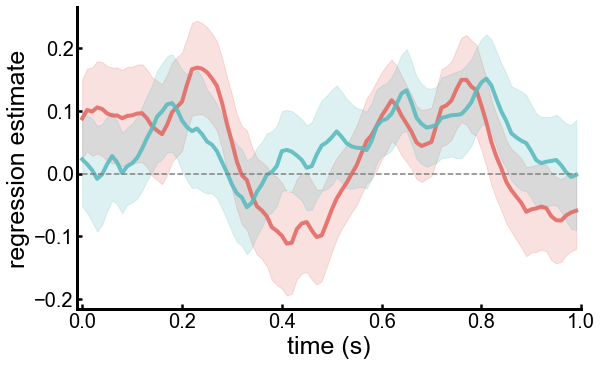

In [97]:
line_color = ['#E36A65','#5CBBBF']
# line_color = ['#E36A65','#FF943C']    # 红色橙色 正确快攻击，错误快攻击  DE6B48  FFADC6

figsize=(10,6) 
title_size=20
legend_size=15

ticksize=10
subplots_adjust=[0.15, 0.15, 0.85, 0.85]


import matplotlib.pyplot as plt
import numpy as np
import os

# if not os.path.exists(result_path):
# os.mkdir(result_path)    
# # plot for each ROI
# for ROI_num in range(len(permutation_cluster_result['ROI_name'])):

event_0_line_color = line_color[0]
event_1_line_color = line_color[1]

# the number of time axis
times = data1.times

plt.close('all')
plt.rcParams['figure.figsize'] = figsize # 设置figure_size尺寸
# plt.title('ROI: '+ roi_name, fontdict={'fontsize':title_size})

epoch_mean={}
epoch_mean[0] = np.squeeze(np.average(data1.data, axis=0))
epoch_mean[1] = np.squeeze(np.average(data2.data, axis=0))

plt.plot(times, epoch_mean[0], color=line_color[0], alpha=0.9, linewidth=4) # , linestyle='--')
plt.plot(times, epoch_mean[1], color=line_color[1], alpha=0.9, linewidth=4) # , linestyle='--')

# 标注哪条线是哪个event
#legend_font = {'family': fontproperties}
# plt.legend(['Fast Escaped', 'Slow Escaped'], fontsize=legend_size, frameon=False, loc='upper right') #, loc='top')

# 画0s时的分割线 
# plt.axvline(times[101], c="gray", ls = "dashed")
# plt.axvline(times[500], c="gray", ls = "dashed")
plt.plot(times, np.zeros(len(epoch_mean[0])), color="gray", linestyle="--")

# 画误差(std)
std_event0 = np.squeeze(np.std(data1.data, axis=0))
std_event1 = np.squeeze(np.std(data2.data, axis=0))

se_event0 = std_event0/np.sqrt(data1.data.shape[0])
se_event1 = std_event1/np.sqrt(data2.data.shape[0])

plt.fill_between(times, epoch_mean[0] - se_event0, epoch_mean[0] + se_event0, color=line_color[0], alpha=0.2)
plt.fill_between(times, epoch_mean[1] - se_event1, epoch_mean[1] + se_event1, color=line_color[1], alpha=0.2)

min_value_1 = np.min(epoch_mean[0] - se_event0)
min_value_2 = np.min(epoch_mean[1] - se_event1)
min_value = np.min([min_value_1, min_value_2])

# event0 的显著性
for i_c, c in enumerate(clusters_fast):
    c = c[0]
    if cluster_p_values_fast[i_c] <= 0.0167:
        # plt.axvspan(times[c.start], times[c.stop - 1], color='r', alpha=0.3)
        plt.plot(times[c.start : c.stop - 1], epoch_mean[0][c.start : c.stop-1], color=event_0_line_color, alpha=0.9, linewidth=10)
# event1 的显著性
for i_c, c in enumerate(clusters_slow):
    c = c[0]
    if cluster_p_values_slow[i_c] <= 0.0167:
        # plt.axvspan(times[c.start], times[c.stop - 1], color='r', alpha=0.3)
        plt.plot(times[c.start : c.stop - 1], epoch_mean[1][c.start : c.stop-1], color=event_1_line_color, alpha=0.9, linewidth=10)

# event 间的显著性
for i_c, c in enumerate(clusters):
    c = c[0]
    if cluster_p_values[i_c] <= 0.0167:
        
        plt.plot(times[c.start : c.stop - 1], min_value-0.005 * np.ones(len(epoch_mean[0]))[c.start : c.stop-1], color='#5EACFF', alpha=0.9, linewidth=10)


#hf = plt.plot(times, T_obs, 'g')
#plt.legend((h, ), ('cluster p-value < 0.05', ))
plt.subplots_adjust(left=subplots_adjust[0], bottom=subplots_adjust[1], right=subplots_adjust[2], top=subplots_adjust[3], hspace=0.1,wspace=0.1)

plt.xlim([times[0]-0.01, times[-1]+0.01])

plt.yticks(size=ticksize)
plt.xticks(size=ticksize)

spines_width = 3
ax=plt.gca()
ax.spines['top'].set_linewidth(0)
ax.spines['right'].set_linewidth(0)
ax.spines['left'].set_linewidth(spines_width)
ax.spines['bottom'].set_linewidth(spines_width)
# sns.despine()

# 坐标轴刻度粗细,朝内
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['ytick.major.size'] = 5
plt.rcParams['xtick.major.width'] = 2.5
plt.rcParams['ytick.major.width'] = 2.5
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
# plt.set_ylabel("Escape Accuracy", size=ticksize, fontproperties='Arial')

labelsize=25
plt.xlabel("time (s)", fontsize=labelsize, fontproperties='Arial')
plt.ylabel("regression estimate", size=labelsize, fontproperties='Arial')

# 坐标的粗细
ticksize = 20
plt.yticks(size=ticksize, fontproperties='Arial')
plt.xticks(size=ticksize, fontproperties='Arial')
# plt.savefig(r'D:\Desktop\项目\seeg\画图\hga_all_bipolar\decision_hpc.jpg',dpi=300, overwrite=True)
# plt.savefig(result_path + '/' + permutation_cluster_result['ROI_name'][ROI_num] + ".png", overwrite=True)

In [94]:
print('fast')
print(clusters_fast, cluster_p_values_fast)
print('slow')
print(clusters_slow, cluster_p_values_slow)
print('compare')
print(clusters, cluster_p_values)

fast
[] []
slow
[] []
compare
[] []
